<a href="https://colab.research.google.com/github/donmatthiuz/DeepLearning/blob/lab6/lab6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratorio 10 parte 2

Usaremos la LSTM del laboratorio 6, no haremos ningún cambio. 

In [1]:
import collections
import time

import datasets
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import tqdm
import transformers


/home/ppguz/DeepLearning/deep/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
train_data, test_data = datasets.load_dataset("imdb", split=["train", "test"])


Generating unsupervised split: 100%|██████████| 50000/50000 [00:00<00:00, 426746.54 examples/s]


### Tokenizacion

In [3]:
transformer_name = "bert-base-uncased"

tokenizer = transformers.AutoTokenizer.from_pretrained(transformer_name)
def tokenize_and_numericalize_example(example, tokenizer):
    ids = tokenizer(example["text"], truncation=True)["input_ids"]
    return {"ids": ids}

In [4]:
train_data = train_data.map(
    tokenize_and_numericalize_example, fn_kwargs={"tokenizer": tokenizer}
)
test_data = test_data.map(
    tokenize_and_numericalize_example, fn_kwargs={"tokenizer": tokenizer}
)

Map: 100%|██████████| 25000/25000 [00:13<00:00, 1900.22 examples/s]


### Vocabulario



In [5]:
# Obtener vocabulario completo
vocab = tokenizer.get_vocab()
print("Tamaño vocabulario:", len(vocab))

# Buscar ID de un token
token_id = tokenizer.convert_tokens_to_ids("hello")
print("ID de 'hello':", token_id)

# Convertir ID a token
token = tokenizer.convert_ids_to_tokens(7592)
print("Token 7592:", token)


Tamaño vocabulario: 30522
ID de 'hello': 7592
Token 7592: hello


### Conversion a torchs


In [6]:
test_size = 0.25

train_valid_data = train_data.train_test_split(test_size=test_size)
train_data = train_valid_data["train"]
valid_data = train_valid_data["test"]
train_data = train_data.with_format(type="torch", columns=["ids", "label"])
valid_data = valid_data.with_format(type="torch", columns=["ids", "label"])
test_data = test_data.with_format(type="torch", columns=["ids", "label"])

### Creacion de Baches


In [7]:
pad_index = tokenizer.pad_token_id

def get_collate_fn(pad_index):
    def collate_fn(batch):
        batch_ids = [i["ids"] for i in batch]
        batch_ids = nn.utils.rnn.pad_sequence(
            batch_ids, padding_value=pad_index, batch_first=True
        )
        batch_label = [i["label"] for i in batch]
        batch_label = torch.stack(batch_label)
        batch = {"ids": batch_ids, "label": batch_label}
        return batch

    return collate_fn
def get_data_loader(dataset, batch_size, pad_index, shuffle=False):
    collate_fn = get_collate_fn(pad_index)
    data_loader = torch.utils.data.DataLoader(
        dataset=dataset,
        batch_size=batch_size,
        collate_fn=collate_fn,
        shuffle=shuffle,
    )
    return data_loader
batch_size = 8

train_data_loader = get_data_loader(train_data, batch_size, pad_index, shuffle=True)
valid_data_loader = get_data_loader(valid_data, batch_size, pad_index)
test_data_loader = get_data_loader(test_data, batch_size, pad_index)

#### LSTM

In [9]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, num_layers):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=False
        )
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # x: [batch_size, seq_len]
        embedded = self.embedding(x)  # [batch_size, seq_len, embedding_dim]
        output, (hidden, cell) = self.lstm(embedded)
        # hidden: [num_layers, batch_size, hidden_dim]
        last_hidden = hidden[-1]  # [batch_size, hidden_dim]
        out = self.fc(last_hidden)  # [batch_size, output_dim]
        return out

## Entrenamiento

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def evaluate(model, data_loader, criterion):
    model.eval()
    epoch_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for batch in data_loader:
            ids = batch["ids"].to(device)
            labels = batch["label"].to(device)
            outputs = model(ids)
            loss = criterion(outputs, labels)
            epoch_loss += loss.item() * labels.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return epoch_loss / total, correct / total

In [11]:
def train_model(model, train_loader, valid_loader, criterion, optimizer, num_epochs):
    model = model.to(device)
    history = {"train_loss": [], "valid_loss": [], "valid_acc": []}

    start_time_total = time.time()
    for epoch in range(num_epochs):
        model.train()
        start_time_epoch = time.time()
        epoch_loss = 0
        for batch in train_loader:
            ids = batch["ids"].to(device)
            labels = batch["label"].to(device)

            optimizer.zero_grad()
            outputs = model(ids)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * labels.size(0)

        epoch_loss /= len(train_loader.dataset)
        valid_loss, valid_acc = evaluate(model, valid_loader, criterion)
        epoch_time = time.time() - start_time_epoch

        history["train_loss"].append(epoch_loss)
        history["valid_loss"].append(valid_loss)
        history["valid_acc"].append(valid_acc)

        print(
            f"Epoch {epoch+1}/{num_epochs} | "
            f"Train Loss: {epoch_loss:.4f} | "
            f"Valid Loss: {valid_loss:.4f} | "
            f"Valid Acc: {valid_acc:.4f} | "
            f"Time: {epoch_time:.2f}s"
        )

    total_time = time.time() - start_time_total
    print(f"Total Training Time: {total_time:.2f}s")
    print(f"Trainable Parameters: {count_parameters(model)}")
    return history


In [12]:
embedding_dim = 100      # Dimensión de los embeddings
hidden_dim = 256
num_layers = 2           # Número de capas RNN/LSTM
output_dim = 2           # Número de clases
num_epochs = 20
learning_rate = 0.001

In [14]:
# Inicializamos modelos
vocab_size = len(tokenizer)  # tamaño del vocabulario

lstm_model = LSTMClassifier(vocab_size, embedding_dim, hidden_dim, output_dim, num_layers)

# Optimizadores
optimizer_lstm = torch.optim.Adam(lstm_model.parameters(), lr=learning_rate)

# Función de pérdida
criterion = nn.CrossEntropyLoss()


# Entrenar LSTM
print("\nEntrenando LSTM...")
history_lstm = train_model(lstm_model, train_data_loader, valid_data_loader, criterion, optimizer_lstm, num_epochs)



Entrenando LSTM...
Epoch 1/20 | Train Loss: 0.6945 | Valid Loss: 0.6937 | Valid Acc: 0.5046 | Time: 94.24s
Epoch 2/20 | Train Loss: 0.6937 | Valid Loss: 0.6933 | Valid Acc: 0.4995 | Time: 94.13s
Epoch 3/20 | Train Loss: 0.6932 | Valid Loss: 0.6936 | Valid Acc: 0.4989 | Time: 95.40s
Epoch 4/20 | Train Loss: 0.6933 | Valid Loss: 0.6932 | Valid Acc: 0.4994 | Time: 94.85s
Epoch 5/20 | Train Loss: 0.6934 | Valid Loss: 0.6931 | Valid Acc: 0.5027 | Time: 95.64s
Epoch 6/20 | Train Loss: 0.6932 | Valid Loss: 0.6931 | Valid Acc: 0.5005 | Time: 93.25s
Epoch 7/20 | Train Loss: 0.6940 | Valid Loss: 0.6930 | Valid Acc: 0.5061 | Time: 92.25s
Epoch 8/20 | Train Loss: 0.6907 | Valid Loss: 0.6940 | Valid Acc: 0.5024 | Time: 90.86s
Epoch 9/20 | Train Loss: 0.6812 | Valid Loss: 0.6989 | Valid Acc: 0.5104 | Time: 91.71s
Epoch 10/20 | Train Loss: 0.6563 | Valid Loss: 0.7342 | Valid Acc: 0.5096 | Time: 91.03s
Epoch 11/20 | Train Loss: 0.6127 | Valid Loss: 0.6183 | Valid Acc: 0.6950 | Time: 93.83s
Epoch 12/2

In [17]:
import matplotlib.pyplot as plt

def plot_training_history(history_lstm):
    epochs = range(1, len(history_lstm["train_loss"]) + 1)

    plt.figure(figsize=(12, 5))

    # --- Gráfica de pérdidas ---
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history_lstm["train_loss"], label="LSTM - Train Loss", marker='s')
    plt.plot(epochs, history_lstm["valid_loss"], label="LSTM - Valid Loss", marker='s', linestyle='--')
    plt.title("Evolución de la Pérdida")
    plt.xlabel("Épocas")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    # --- Gráfica de Accuracy ---
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history_lstm["valid_acc"], label="LSTM - Valid Accuracy", marker='s')
    plt.title("Evolución de la Precisión (Accuracy)")
    plt.xlabel("Épocas")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()


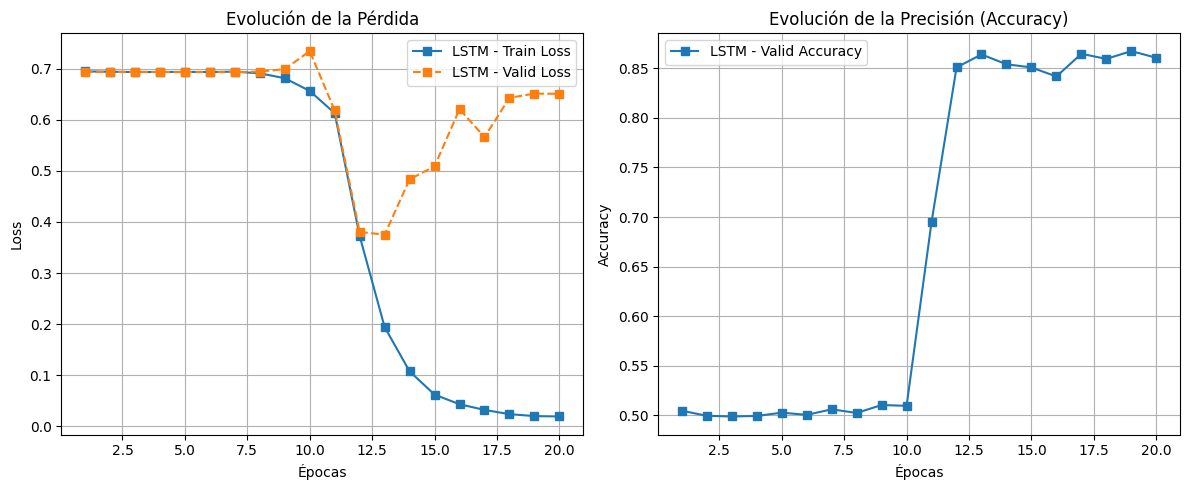

In [18]:
plot_training_history(history_lstm)


In [63]:
import shap
import torch
import numpy as np

# --- STEP 1: extract variable-length data ---
background = next(iter(train_data_loader))["ids"][:20]
batch = next(iter(test_data_loader))["ids"][:3]

# --- STEP 2: find max length among all samples ---
max_len = max(
    max(x.size(0) for x in background),
    max(x.size(0) for x in batch)
)

# --- STEP 3: pad sequences manually for SHAP only ---
def pad_seq_list(seq_list, max_len, pad_value):
    padded = []
    for seq in seq_list:
        if seq.size(0) < max_len:
            seq = torch.nn.functional.pad(
                seq, (0, max_len - seq.size(0)), value=pad_value
            )
        padded.append(seq)
    return torch.stack(padded)

pad_value = tokenizer.pad_token_id
background_padded = pad_seq_list(background, max_len, pad_value).cpu().numpy()
batch_padded = pad_seq_list(batch, max_len, pad_value).cpu().numpy()

# --- STEP 4: define predict function ---
def predict(x):
    x = torch.tensor(x).long().to(device)
    with torch.no_grad():
        logits = lstm_model(x)
        probs = torch.softmax(logits, dim=1)
    return probs.cpu().numpy()

# --- STEP 5: run KernelExplainer ---
explainer = shap.KernelExplainer(predict, background_padded)
shap_values = explainer.shap_values(batch_padded, nsamples=100)

# --- STEP 6: convert ids -> tokens ---
token_lists = [tokenizer.convert_ids_to_tokens(seq) for seq in batch_padded]




 67%|██████▋   | 2/3 [00:00<00:00,  5.22it/s]/home/ppguz/DeepLearning/deep/lib/python3.10/site-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 8 iterations, i.e. alpha=7.007e-02, with an active set of 8 regressors, and the smallest cholesky pivot element being 8.429e-08. Reduce max_iter or increase eps parameters.
  warnings.warn(
100%|██████████| 3/3 [00:00<00:00,  5.67it/s]


## SHAP con LSTM

### 1. Preparación de Datos
- Extrae **20 muestras de referencia** (background) del conjunto de entrenamiento
- Extrae **3 muestras a explicar** del conjunto de prueba
- Aplica **padding** para que todas las secuencias tengan la misma longitud

### 2. Función de Predicción
```python
def predict_single_output(x):
    return probs[:, 1:2].cpu().numpy() 
```
Define cómo el modelo predice, devolviendo solo la probabilidad de sentimiento POSITIVO.

### 3. Cálculo de SHAP Values
```python
explainer = shap.KernelExplainer(predict_single_output, background_padded)
shap_values = explainer.shap_values(batch_padded, nsamples=100)
```
**Esto es lo más importante:** Calcula cuánto contribuye cada palabra a la predicción.

**Resultado por palabra:**
- **Positivo (+)**: Empuja hacia sentimiento POSITIVO
- **Negativo (-)**: Empuja hacia sentimiento NEGATIVO  
- **Cercano a 0**: No influye en la decisión

### 4. Visualización
Crea gráficos de barras mostrando las **top 20 palabras más influyentes**:
- 🟢 **Verde**: Palabras que aumentan sentimiento POSITIVO
- 🔴 **Rojo**: Palabras que aumentan sentimiento NEGATIVO

## Ejemplo de Interpretación

**Review:** "This movie is absolutely terrible"
```
terrible       ████████ -0.18  (ROJO - fuerte influencia negativa)
absolutely     ███ -0.05       (ROJO - refuerza lo negativo)
movie          █ +0.001        (VERDE - casi neutral)
```

100%|██████████| 3/3 [00:00<00:00,  5.20it/s]


Generando visualizaciones...



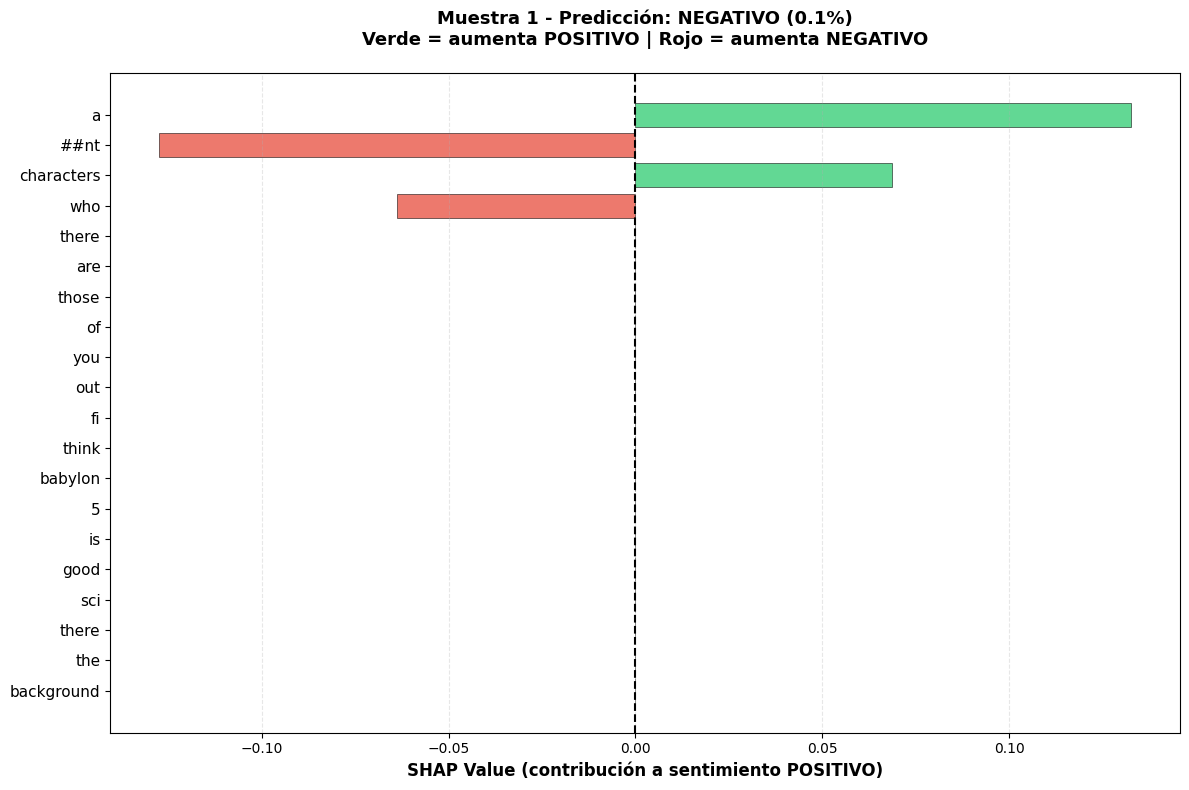

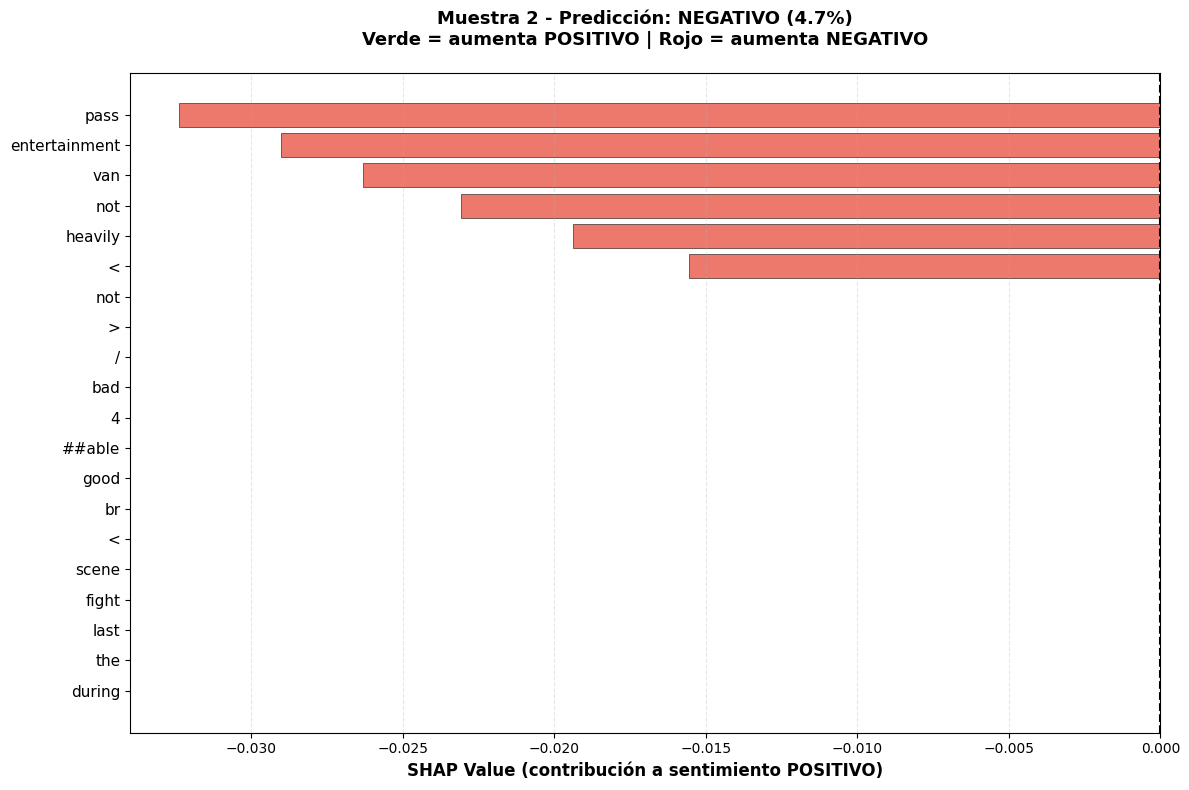

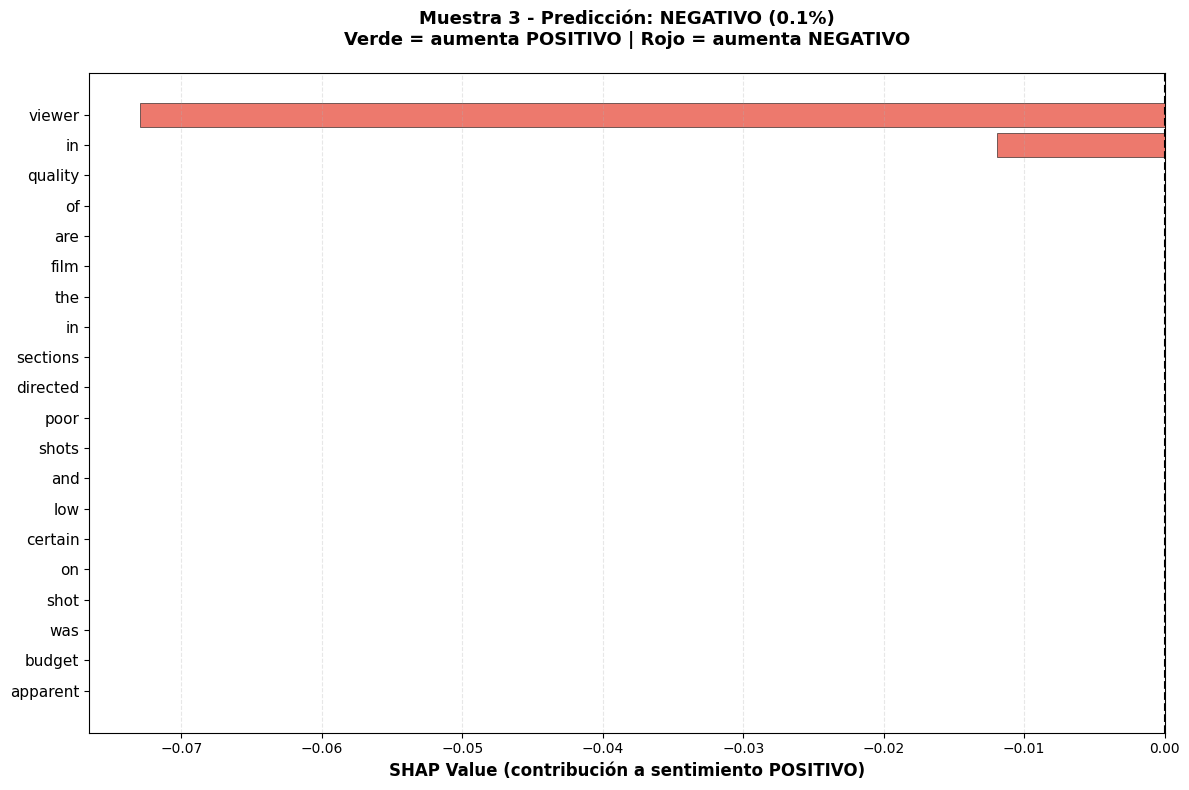

In [72]:
import shap


background = next(iter(train_data_loader))["ids"][:20]  
batch = next(iter(test_data_loader))["ids"][:3]      

# Encontrar la longitud máxima
max_len = max(
    max(x.size(0) for x in background),
    max(x.size(0) for x in batch)
)


def pad_seq_list(seq_list, max_len, pad_value):
    padded = []
    for seq in seq_list:
        if seq.size(0) < max_len:
            seq = torch.nn.functional.pad(
                seq, (0, max_len - seq.size(0)), value=pad_value
            )
        padded.append(seq)
    return torch.stack(padded)


pad_value = tokenizer.pad_token_id
background_padded = pad_seq_list(background, max_len, pad_value).cpu().numpy()
batch_padded = pad_seq_list(batch, max_len, pad_value).cpu().numpy()


def predict_single_output(x):
    """Predice la probabilidad de sentimiento POSITIVO"""
    x = torch.tensor(x).long().to(device)
    with torch.no_grad():
        logits = lstm_model(x)
        probs = torch.softmax(logits, dim=1)
    return probs[:, 1:2].cpu().numpy() 




explainer = shap.KernelExplainer(predict_single_output, background_padded)
shap_values = explainer.shap_values(batch_padded, nsamples=100)


token_lists = [tokenizer.convert_ids_to_tokens(seq) for seq in batch_padded]


for sample_idx in range(len(batch_padded)):
    
    # Filtrar tokens de padding
    mask = batch_padded[sample_idx] != pad_value
    tokens_reales = [token_lists[sample_idx][i] for i in range(len(mask)) if mask[i]]
    

    if isinstance(shap_values, list):
        shap_sample = np.array(shap_values)[sample_idx]
    else:
        shap_sample = shap_values[sample_idx]
    
    # Aplicar máscara para quitar padding
    shap_reales = shap_sample[mask].flatten()
    
 
    pred = predict_single_output(batch_padded[sample_idx:sample_idx+1])[0][0]
    sentiment = "POSITIVO ✓" if pred > 0.5 else "NEGATIVO ✗"
    
print("Generando visualizaciones...\n")

for sample_idx in range(len(batch_padded)):
    # Preparar datos
    mask = batch_padded[sample_idx] != pad_value
    tokens_reales = [token_lists[sample_idx][i] for i in range(len(mask)) if mask[i]]
    
    if isinstance(shap_values, list):
        shap_sample = np.array(shap_values)[sample_idx]
    else:
        shap_sample = shap_values[sample_idx]
    
    shap_reales = shap_sample[mask].flatten()
    
    # Filtrar tokens especiales y puntuación
    filtered_tokens = []
    filtered_shap = []
    
    for i, token in enumerate(tokens_reales):
        if token not in ['[CLS]', '[SEP]', ',', '.', '!', '?', '"', "'", '(', ')', '-', ':', ';', '[', ']']:
            filtered_tokens.append(token)
            filtered_shap.append(shap_reales[i])
    
    # Seleccionar top 20 por valor absoluto
    abs_sorted = np.argsort(np.abs(filtered_shap))[-20:]
    
    # Crear gráfico
    fig, ax = plt.subplots(figsize=(12, 8))
    colors = ['#2ecc71' if filtered_shap[i] > 0 else '#e74c3c' for i in abs_sorted]
    
    ax.barh(range(len(abs_sorted)), 
            [filtered_shap[i] for i in abs_sorted],
            color=colors, alpha=0.75, edgecolor='black', linewidth=0.5)
    
    ax.set_yticks(range(len(abs_sorted)))
    ax.set_yticklabels([filtered_tokens[i] for i in abs_sorted], fontsize=11)
    ax.set_xlabel('SHAP Value (contribución a sentimiento POSITIVO)', fontsize=12, fontweight='bold')
    
    pred = predict_single_output(batch_padded[sample_idx:sample_idx+1])[0][0]
    sentiment = "POSITIVO" if pred > 0.5 else "NEGATIVO"
    
    ax.set_title(f'Muestra {sample_idx + 1} - Predicción: {sentiment} ({pred:.1%})\n' +
                 f'Verde = aumenta POSITIVO | Rojo = aumenta NEGATIVO', 
                 fontsize=13, fontweight='bold', pad=20)
    
    ax.axvline(x=0, color='black', linestyle='--', linewidth=1.5)
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    
    plt.tight_layout()
    plt.show()


Tomamos 3 muestres y en todas vemos que salió que la reseña es negativa a pesar de que había palabras consideradas como positivas. Algo interesante es ver que palabras que uno creería como positivas como "entertainment" en realidad son consideradasnegativas, esto puede ser por el contexto ya que posiblemente en las reseñas que usan esta palabra se use despectivamente como por ejemplo "cheap entertainment", etc. 

## Conclusiones

- SHAP resultó ser bastante útil pues fue de gran ayuda para entender en que se basó el modelo para hacer cierta predicción. Esto es importante pues sabemos que a veces la información que usamos puede contener sesgos y esto puede provocar que los modelos no hagan prediccciones adecuadas y que afecten la toma de decisiones, sabiendo porque el modelo toma una decisión podemos mejorarlo y corregir errores. 